In [2]:
!pip install prophet

  Using cached prophet-1.3.0-py3-none-win_amd64.whl.metadata (3.6 kB)
  Using cached cmdstanpy-1.3.0-py3-none-any.whl.metadata (4.2 kB)
  Using cached holidays-0.94-py3-none-any.whl.metadata (52 kB)
  Using cached importlib_resources-7.1.0-py3-none-any.whl.metadata (4.0 kB)
  Using cached stanio-0.5.1-py3-none-any.whl.metadata (1.6 kB)
Using cached prophet-1.3.0-py3-none-win_amd64.whl (12.1 MB)
Using cached cmdstanpy-1.3.0-py3-none-any.whl (99 kB)
Using cached holidays-0.94-py3-none-any.whl (1.4 MB)
Using cached importlib_resources-7.1.0-py3-none-any.whl (37 kB)
Using cached stanio-0.5.1-py3-none-any.whl (8.1 kB)


In [3]:
from prophet import Prophet

m = Prophet()
print("Prophet working ✅")

Prophet working ✅


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries loaded")

✅ Libraries loaded


##  Create Daily Orders Time Series

In [5]:

df = pd.read_csv("clean_data_full.csv")
# Preview the data
print(df.head())
print(df.dtypes)



     order_id customer_id restaurant_id                   restaurant_name  \
0  ORD0000001  CUST010401      REST0487         Radhakrishnan Ltd Kitchen   
1  ORD0000002  CUST007934      REST0116  Bera, Narula and Sridhar Kitchen   
2  ORD0000003  CUST007327      REST0361    Nayak, Mann and Thaker Kitchen   
3  ORD0000004  CUST011260      REST0180                Chahal Inc Kitchen   
4  ORD0000005  CUST004397      REST0152  Khatri, Bhatia and Mutti Kitchen   

            order_date       city        cuisine  order_value  discount_pct  \
0  2024-06-12 21:47:00  Bengaluru  Rolls & Wraps       127.12             5   
1  2023-11-04 20:56:00     Mumbai  Rolls & Wraps       144.27            10   
2  2024-03-11 08:29:00  Bengaluru       Desserts       241.70            25   
3  2023-10-02 16:56:00     Mumbai        Biryani       537.42            10   
4  2023-12-14 18:02:00     Mumbai  Rolls & Wraps       147.87            15   

   discount_amount  ...  order_month  order_weekday  delivery_

In [6]:
# ── Adjust these column names to match YOUR dataset ──────────────────────
DATE_COL   = 'order_date'   # The column with order dates
CITY_COL   = 'city'         # The column with city names
ORDER_COL  = 'order_id'     # The column to count (each row = 1 order)
# ─────────────────────────────────────────────────────────────────────────

# Parse dates
df[DATE_COL] = pd.to_datetime(df[DATE_COL])



In [7]:
# ── OVERALL daily time series ─────────────────────────────────────────────
daily_orders = (
    df.groupby(DATE_COL)[ORDER_COL]
    .count()                        # Count orders per day
    .reset_index()
    .rename(columns={DATE_COL: 'ds', ORDER_COL: 'y'})  # Prophet needs 'ds' and 'y'
)



In [9]:
# Sort chronologically and fill missing dates with 0
daily_orders = daily_orders.sort_values('ds').set_index('ds')
daily_orders = daily_orders.asfreq('D', fill_value=0).reset_index()

print(f"\n📅 Date range: {daily_orders['ds'].min()} → {daily_orders['ds'].max()}")
print(f"📊 Total days: {len(daily_orders)}")
print(daily_orders.head())


📅 Date range: 2023-01-01 00:39:00 → 2024-12-31 00:39:00
📊 Total days: 731
                   ds  y
0 2023-01-01 00:39:00  1
1 2023-01-02 00:39:00  0
2 2023-01-03 00:39:00  0
3 2023-01-04 00:39:00  0
4 2023-01-05 00:39:00  0


 ## Train Prophet Model + Add Indian Holidays

In [11]:
def build_prophet_model(df_ts, country='IN'):
    
    m = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        seasonality_mode='multiplicative',
        changepoint_prior_scale=0.1,
        seasonality_prior_scale=10.0,
        interval_width=0.95
    )
    
    m.add_country_holidays(country_name=country)
    m.fit(df_ts)
    
    print(f"✅ Model trained on {len(df_ts)} days")
    return m

In [12]:
model_overall = build_prophet_model(daily_orders)

16:43:37 - cmdstanpy - INFO - Chain [1] start processing
16:43:38 - cmdstanpy - INFO - Chain [1] done processing


✅ Model trained on 731 days


In [13]:
# Verify holidays were added
print(f"\n🎉 Indian holidays loaded: {len(model_overall.train_holiday_names)} events")


🎉 Indian holidays loaded: 16 events


In [ ]:
def generate_forecast(model, periods=30):
    """
    Create future dataframe and generate predictions.
    
    Returns:
        forecast DataFrame with yhat, yhat_lower, yhat_upper
    """
    # Create future dates (historical + 30 new days)
    future = model.make_future_dataframe(periods=periods, freq='D')
    
    # Generate forecast
    forecast = model.predict(future)
    
    # Extract key columns
    forecast_clean = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper',
                                'trend', 'weekly', 'yearly', 'holidays']]
    
    # Round predictions (can't have fractional orders)
    forecast_clean = forecast_clean.copy()
    forecast_clean[['yhat', 'yhat_lower', 'yhat_upper']] = \
        forecast_clean[['yhat', 'yhat_lower', 'yhat_upper']].round(0).astype(int)
    
    # Clip negatives to 0 (orders can't be negative)
    forecast_clean['yhat'] = forecast_clean['yhat'].clip(lower=0)
    forecast_clean['yhat_lower'] = forecast_clean['yhat_lower'].clip(lower=0)
    
    return forecast, forecast_clean


forecast_raw, forecast_clean = generate_forecast(model_overall, periods=30)

# View next 30 days only
next_30 = forecast_clean[forecast_clean['ds'] > daily_orders['ds'].max()].copy()
print(f"\n📈 30-Day Forecast Summary:")
print(f"   Expected orders range: {next_30['yhat'].min()} – {next_30['yhat'].max()} orders/day")
print(f"   Peak day: {next_30.loc[next_30['yhat'].idxmax(), 'ds'].date()} ({next_30['yhat'].max()} orders)")
print(next_30[['ds','yhat','yhat_lower','yhat_upper']].head(10))

## FORECAST FUNCTION

In [14]:
def generate_forecast(model, periods=30):
    
    future = model.make_future_dataframe(periods=periods, freq='D')
    forecast = model.predict(future)

    forecast_clean = forecast[['ds','yhat','yhat_lower','yhat_upper']].copy()
    
    # Clean output
    forecast_clean[['yhat','yhat_lower','yhat_upper']] = \
        forecast_clean[['yhat','yhat_lower','yhat_upper']].round(0).astype(int)

    forecast_clean['yhat'] = forecast_clean['yhat'].clip(lower=0)
    forecast_clean['yhat_lower'] = forecast_clean['yhat_lower'].clip(lower=0)

    return forecast, forecast_clean

In [18]:
forecast_raw, forecast_clean = generate_forecast(model_overall)

# Next 30 days
last_date = daily_orders['ds'].max()
next_30 = forecast_clean[forecast_clean['ds'] > last_date]

print("📈 Forecast Range:", next_30['yhat'].min(), "-", next_30['yhat'].max())
print("🔥 Peak Day:", next_30.loc[next_30['yhat'].idxmax(),'ds'])

📈 Forecast Range: 0 - 0
🔥 Peak Day: 2025-01-01 00:39:00


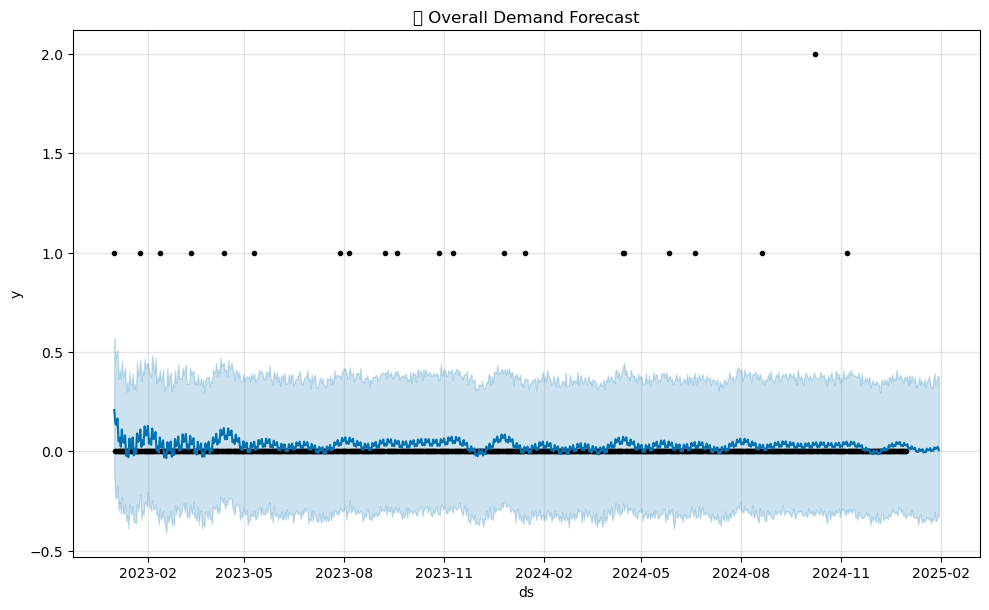

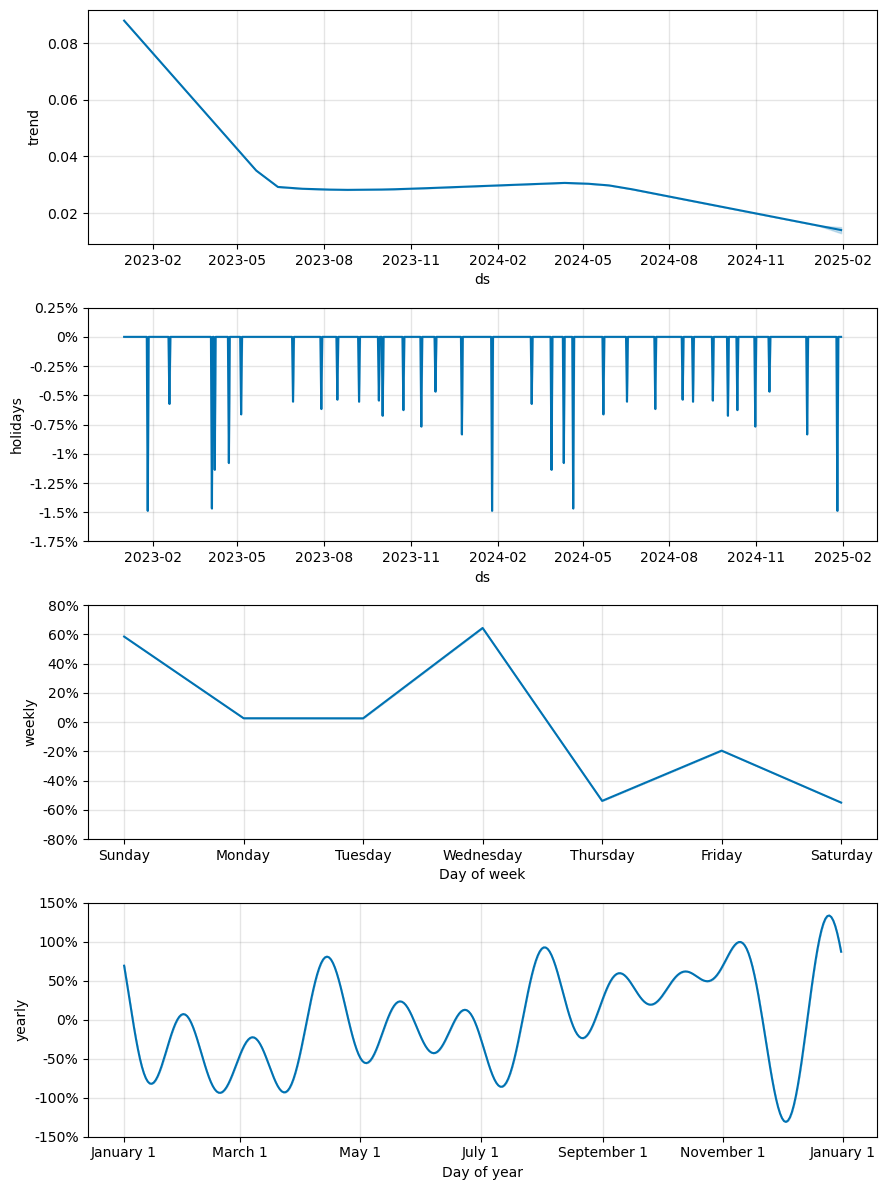

In [19]:
def plot_forecast(model, forecast):
    
    model.plot(forecast)
    plt.title("📦 Overall Demand Forecast")
    plt.show()

    model.plot_components(forecast)
    plt.show()

plot_forecast(model_overall, forecast_raw)

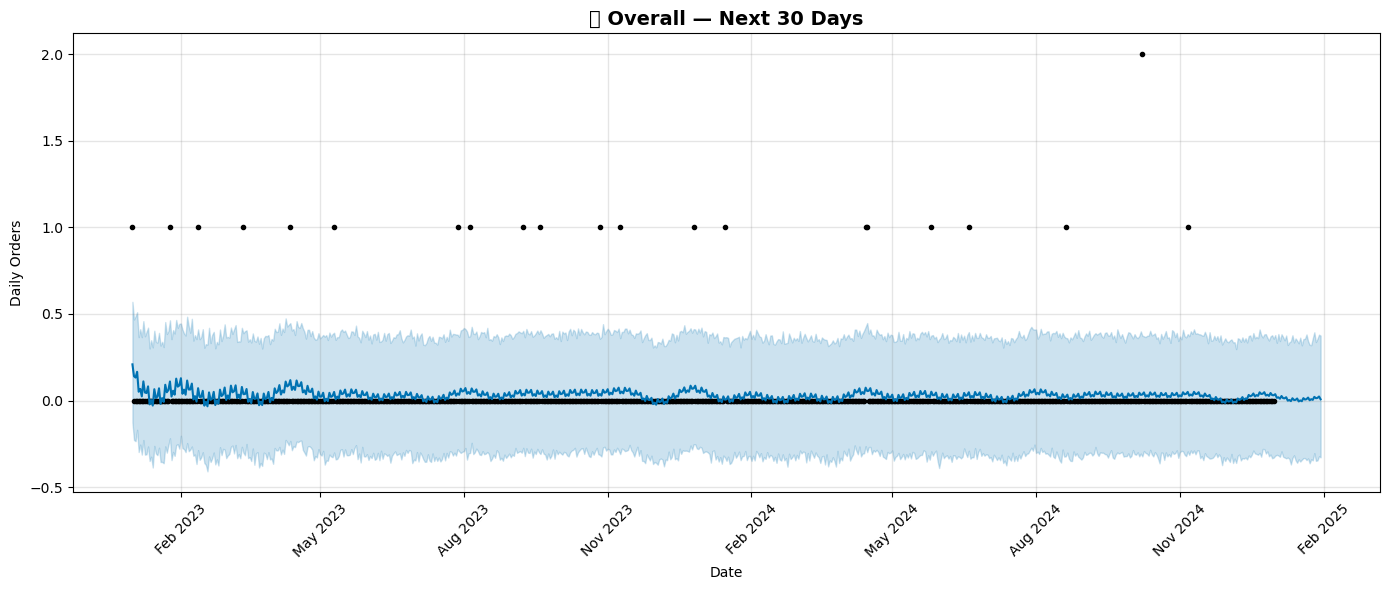

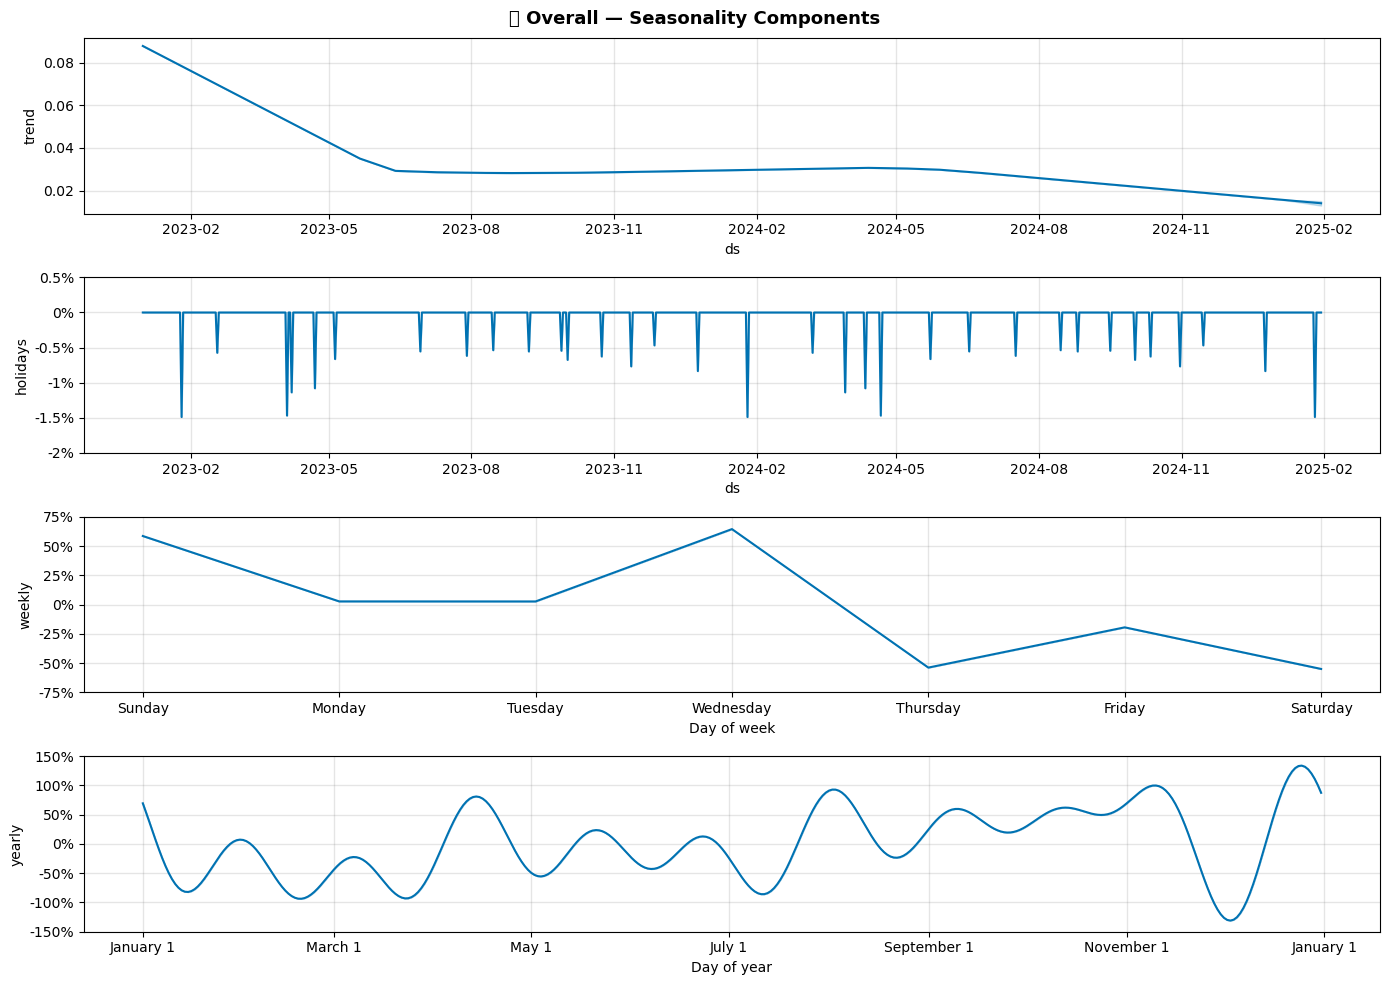

In [20]:
def plot_forecast(model, forecast, title="Overall Order Forecast", save_path=None):
    """Plot the main forecast and seasonal components."""
    
    fig1 = model.plot(forecast, figsize=(14, 6))
    ax = fig1.gca()
    ax.set_title(f'📦 {title} — Next 30 Days', fontsize=14, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Daily Orders')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.xticks(rotation=45)
    plt.tight_layout()
    if save_path:
        fig1.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    
    # ── Component plots (trend + seasonality) ────────────────────────────
    fig2 = model.plot_components(forecast, figsize=(14, 10))
    fig2.suptitle(f'📊 {title} — Seasonality Components', fontsize=13, fontweight='bold')
    plt.tight_layout()
    if save_path:
        comp_path = save_path.replace('.png', '_components.png')
        fig2.savefig(comp_path, dpi=150, bbox_inches='tight')
    plt.show()
    
    return fig1, fig2


fig1, fig2 = plot_forecast(
    model_overall,
    forecast_raw,
    title="Overall",
    save_path="seasonality_components.png"
)

 ## CITY-LEVEL FORECAST


🏙️  Training model for: Bengaluru
   → 731 days | avg 0.0 orders/day


17:00:21 - cmdstanpy - INFO - Chain [1] start processing
17:00:22 - cmdstanpy - INFO - Chain [1] done processing


✅ Model trained on 731 days


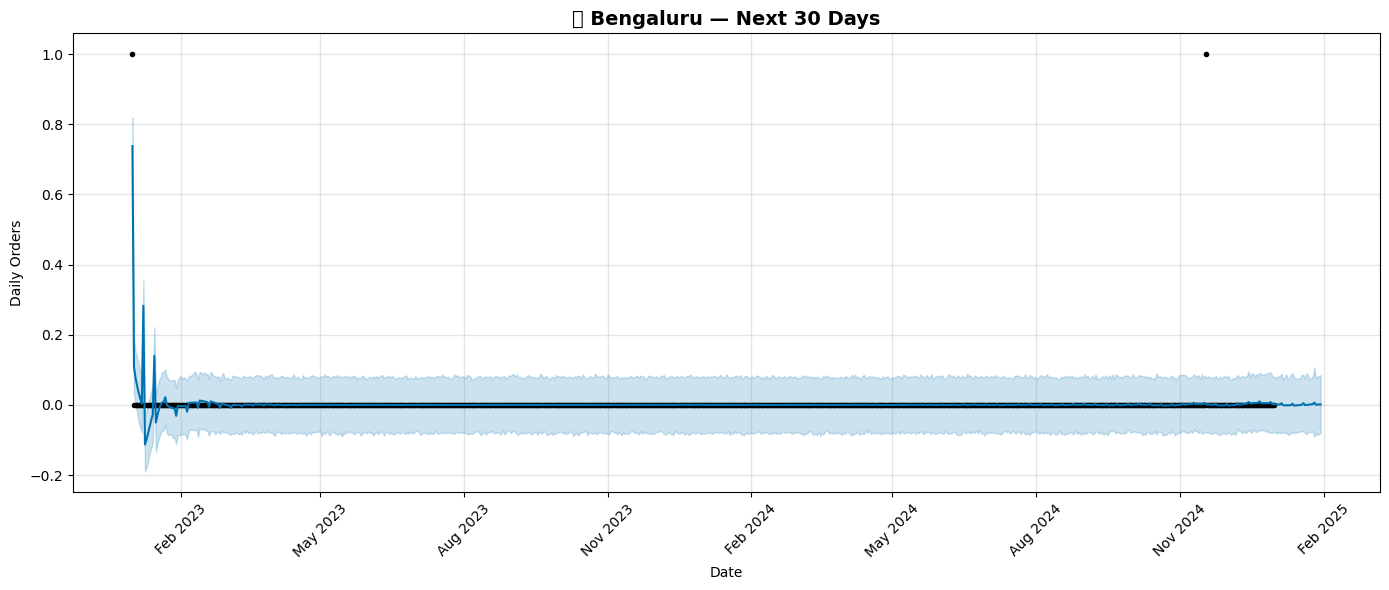

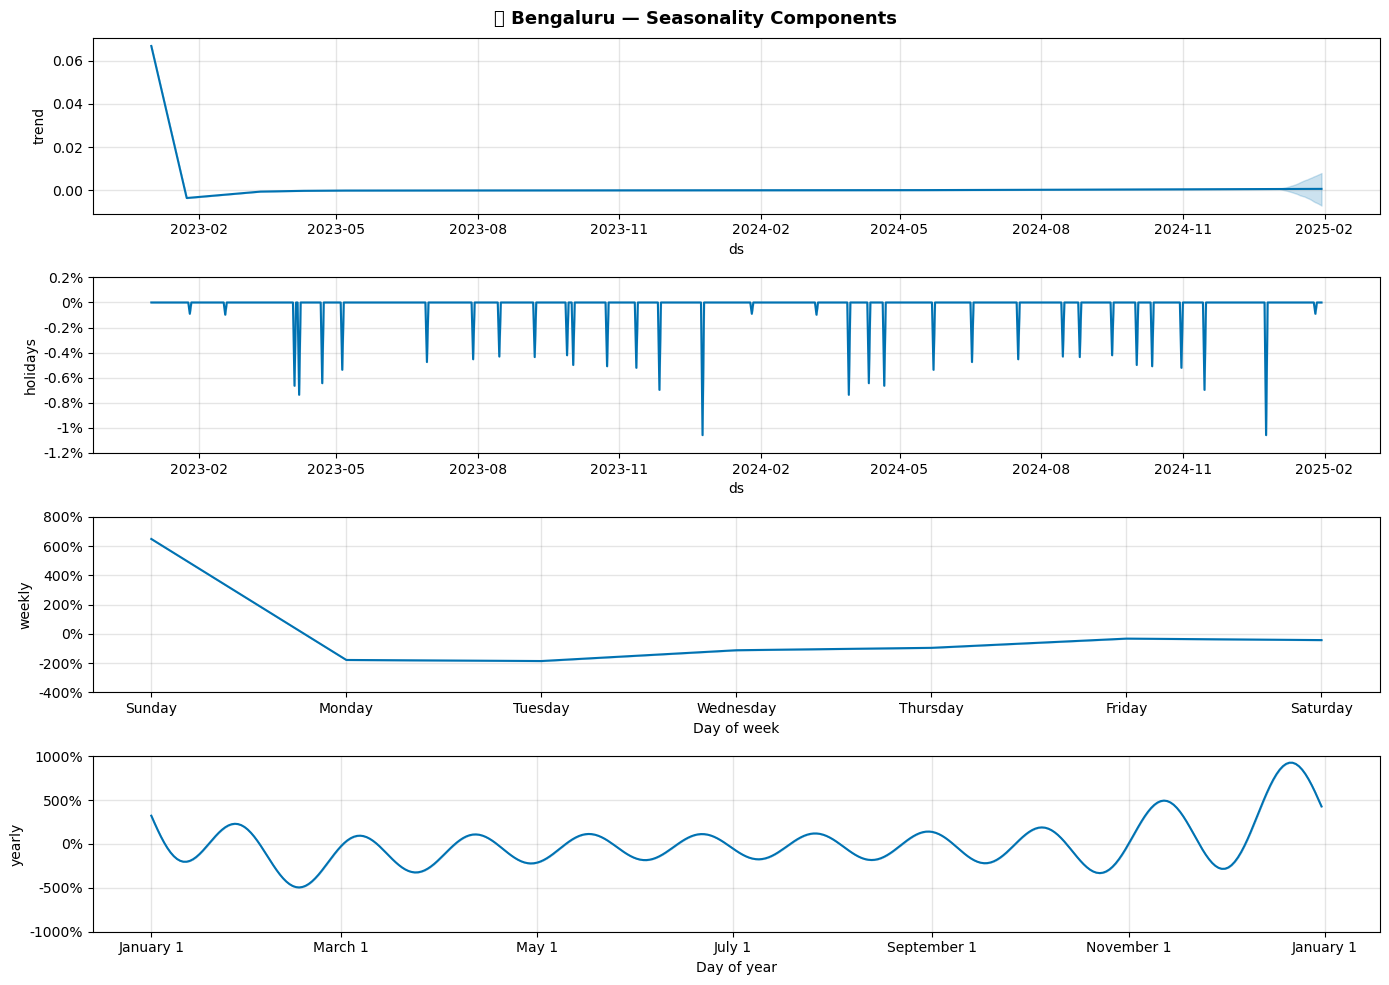

   📈 30-day forecast: 0–0 orders/day
   🔺 Peak: 2025-01-01 (0 orders)

🏙️  Training model for: Mumbai
   → 731 days | avg 0.0 orders/day


17:00:25 - cmdstanpy - INFO - Chain [1] start processing
17:00:25 - cmdstanpy - INFO - Chain [1] done processing


✅ Model trained on 731 days


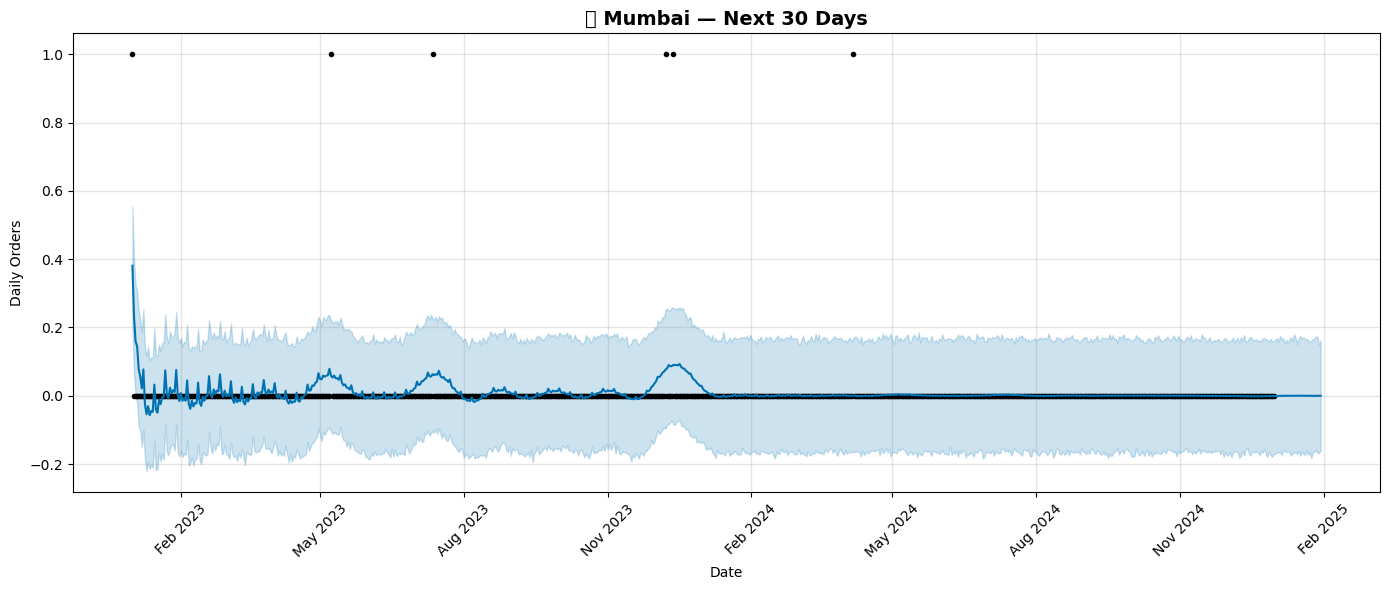

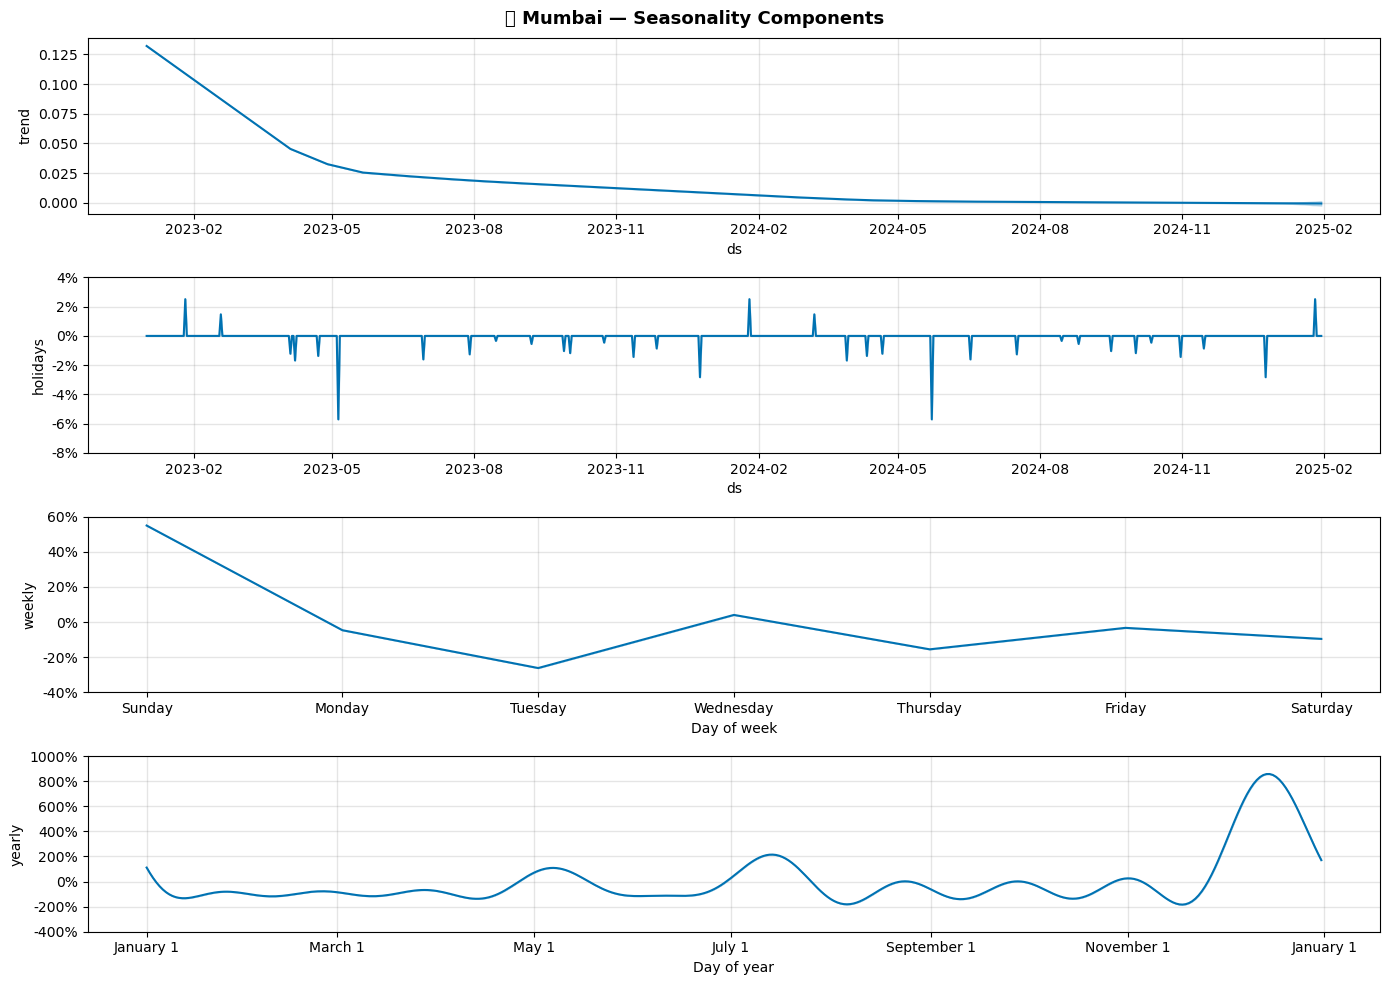

   📈 30-day forecast: 0–0 orders/day
   🔺 Peak: 2025-01-01 (0 orders)

🏙️  Training model for: Delhi
   → 731 days | avg 0.0 orders/day


17:00:29 - cmdstanpy - INFO - Chain [1] start processing
17:00:29 - cmdstanpy - INFO - Chain [1] done processing


✅ Model trained on 731 days


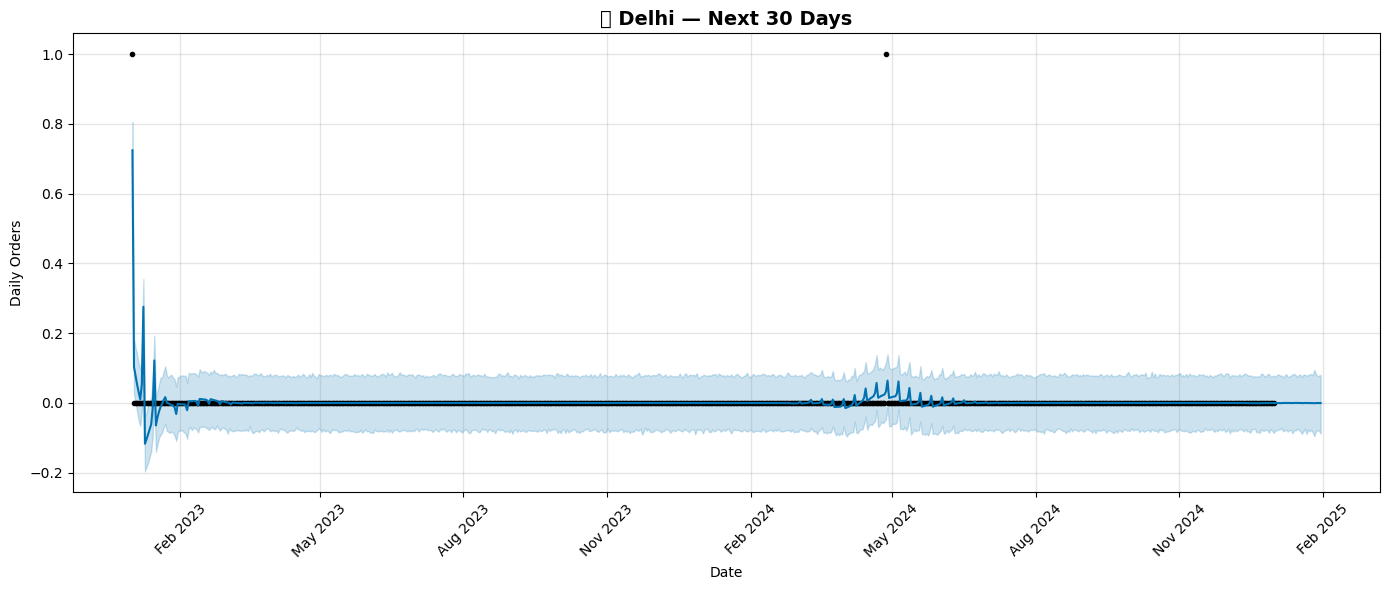

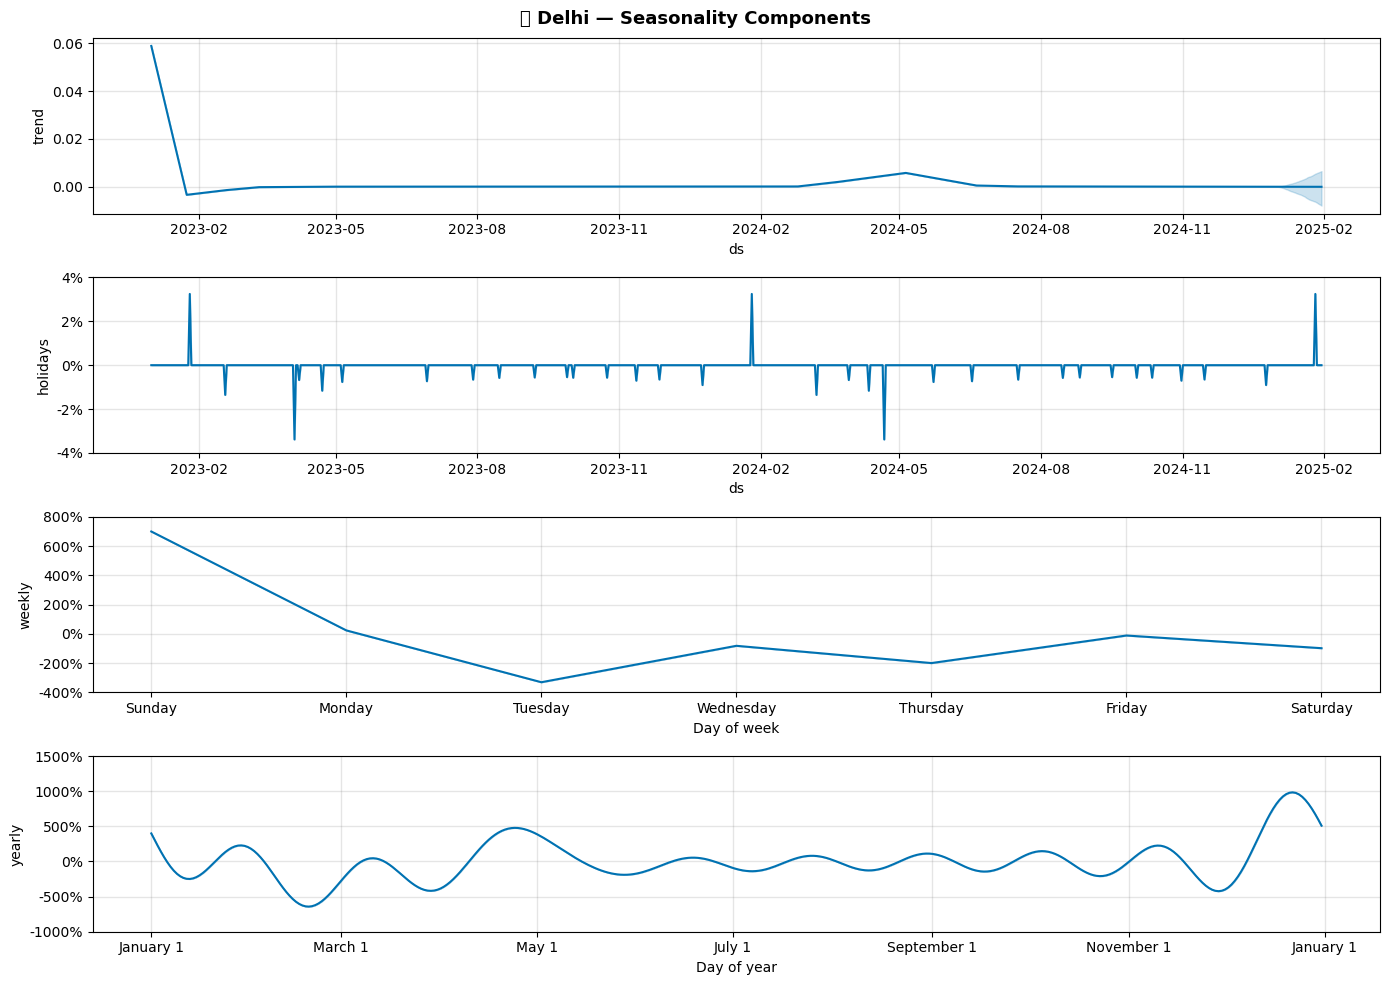

   📈 30-day forecast: 0–0 orders/day
   🔺 Peak: 2025-01-01 (0 orders)

✅ City-level forecasting complete.


In [22]:
TOP_CITIES = ['Bengaluru', 'Mumbai', 'Delhi']

city_forecasts = {}      # Store forecast DataFrames
city_models    = {}      # Store fitted models

for city in TOP_CITIES:
    print(f"\n🏙️  Training model for: {city}")
    
    # Filter orders for this city
    city_df = (
        df[df[CITY_COL] == city]
        .groupby(DATE_COL)[ORDER_COL]
        .count()
        .reset_index()
        .rename(columns={DATE_COL: 'ds', ORDER_COL: 'y'})
        .sort_values('ds')
        .set_index('ds')
        .asfreq('D', fill_value=0)
        .reset_index()
    )
    
    print(f"   → {len(city_df)} days | avg {city_df['y'].mean():.1f} orders/day")
    
    # Train model
    model_city = build_prophet_model(city_df, country='IN')
    
    # Generate forecast
    forecast_city_raw, forecast_city_clean = generate_forecast(model_city, periods=30)
    
    # Store results
    city_models[city]    = model_city
    city_forecasts[city] = forecast_city_clean
    
    # Plot
    plot_forecast(model_city, forecast_city_raw, title=city)
    
    # Print summary
    next30 = forecast_city_clean[forecast_city_clean['ds'] > city_df['ds'].max()]
    print(f"   📈 30-day forecast: {next30['yhat'].min()}–{next30['yhat'].max()} orders/day")
    print(f"   🔺 Peak: {next30.loc[next30['yhat'].idxmax(), 'ds'].date()} ({next30['yhat'].max()} orders)")

print("\n✅ City-level forecasting complete.")

In [25]:
def evaluate_model(model, df_ts, initial_days=365, period_days=30, horizon_days=30):
    """
    Walk-forward cross-validation on historical data.
    """
    
    print("⏳ Running cross-validation...")

    try:
        df_cv = cross_validation(
            model,
            initial=f'{initial_days} days',
            period=f'{period_days} days',
            horizon=f'{horizon_days} days',
            parallel="processes"
        )

        df_perf = performance_metrics(df_cv)

        # Safe extraction
        mae  = df_perf['mae'].mean() if 'mae' in df_perf else None
        mape = df_perf['mape'].mean()*100 if 'mape' in df_perf else None
        rmse = df_perf['rmse'].mean() if 'rmse' in df_perf else None

        print("\n📊 Model Evaluation Results:")
        if mae:
            print(f"   MAE  : {mae:.1f} orders/day")
        if mape:
            print(f"   MAPE : {mape:.2f}%")
        if rmse:
            print(f"   RMSE : {rmse:.1f} orders/day")

        # Interpretation
        if mape:
            if mape < 10:
                rating = "🟢 Excellent (< 10%)"
            elif mape < 20:
                rating = "🟡 Good (10–20%)"
            elif mape < 30:
                rating = "🟠 Acceptable (20–30%)"
            else:
                rating = "🔴 Poor (> 30%)"
            
            print(f"   Forecast Quality: {rating}")

        return df_cv, df_perf

    except Exception as e:
        print("⚠️ Cross-validation failed:", e)
        print("👉 Try reducing initial_days or disabling yearly seasonality")
        return None, None

In [31]:
# ── forecast_30days.csv ───────────────────────────────────────────────────
next_30_export = next_30[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
next_30_export.columns = ['date', 'forecast_orders', 'lower_bound', 'upper_bound']
next_30_export.to_csv('forecast_30days.csv', index=False)
print("✅ Saved: forecast_30days.csv")

# ── forecast_by_city.csv ──────────────────────────────────────────────────
city_rows = []
for city, fc in city_forecasts.items():
    # Get only the future 30 days
    # We need the last date of each city's training data
    city_train_end = (
        df[df[CITY_COL] == city]
        [DATE_COL].max()
    )
    future_fc = fc[fc['ds'] > city_train_end][['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
    future_fc.insert(0, 'city', city)
    city_rows.append(future_fc)

city_forecast_df = pd.concat(city_rows, ignore_index=True)
city_forecast_df.columns = ['city', 'date', 'forecast_orders', 'lower_bound', 'upper_bound']
city_forecast_df.to_csv('forecast_by_city.csv', index=False)
print("✅ Saved: forecast_by_city.csv")

print("\n📁 All outputs saved:")
print("   • forecast_30days.csv")
print("   • forecast_by_city.csv")
print("   • seasonality_components.png")
print("   • seasonality_components_components.png")

✅ Saved: forecast_30days.csv
✅ Saved: forecast_by_city.csv

📁 All outputs saved:
   • forecast_30days.csv
   • forecast_by_city.csv
   • seasonality_components.png
   • seasonality_components_components.png
